In [ ]:
import json
from tqdm import tqdm
from openai import OpenAI
import os

# Create OpenAI client with SSL verification disabled
# API

import httpx
client = OpenAI(
    api_key=api_key,
    http_client=httpx.Client(verify=False)  # Disable SSL verification safely
)

with open('valid_data.json', 'r') as vd:
    valid_json = json.load(vd)

# valid_dic[data['problem_name']]={"natural_s":data["informal_statement"],
#                                  "natural_p":data["informal_proof"], 
#                                  "formal_s":data["formal_statement"]}

# Collect results from LLM in dictionary
results = {}

# Use tqdm for progress bar
for entry in tqdm(valid_json, desc="Processing entries"):
    natural_s = valid_json[entry]["natural_s"]
    natural_p = valid_json[entry]["natural_p"]
    formal_s = valid_json[entry]["formal_s"]

    # Call GPT to perform formal_s to natural language
    prompt = f"""
            Translate the following Isabelle/HOL statement into a clear natural language question that conveys the exact same logical meaning.
            
            Generate only the natural language question written in LaTex, without any additional commentary or explanation.

            Formal Statement:
            {formal_s}

            Natural Language Statement:
            """
    
    # Call GPT
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that translates between formal logic and natural language."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=500,
        n=1,
        stop=None,
        temperature=0.0,
    )

    # Collect Response
    gpt_natural_s = response.choices[0].message.content

    results[entry] = {
        "natural_s": natural_s,
        "natural_p": natural_p,
        "formal_s": formal_s,
        "gpt_natural_s": gpt_natural_s
    }

# Save results to a JSON file
with open('gpt_translations_latex.json', 'w') as out_file:
    json.dump(results, out_file, indent=4)

Average Cosine Similarity: 0.3052


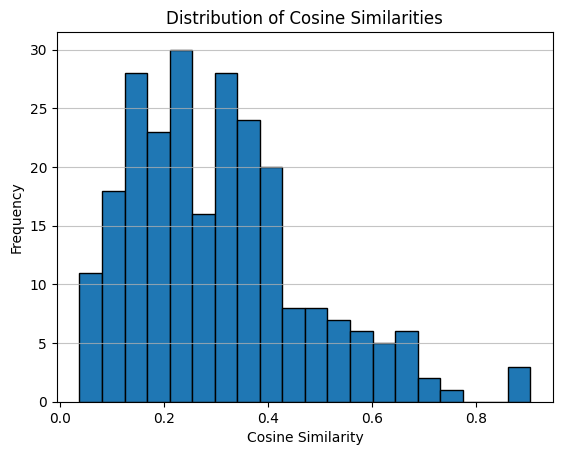

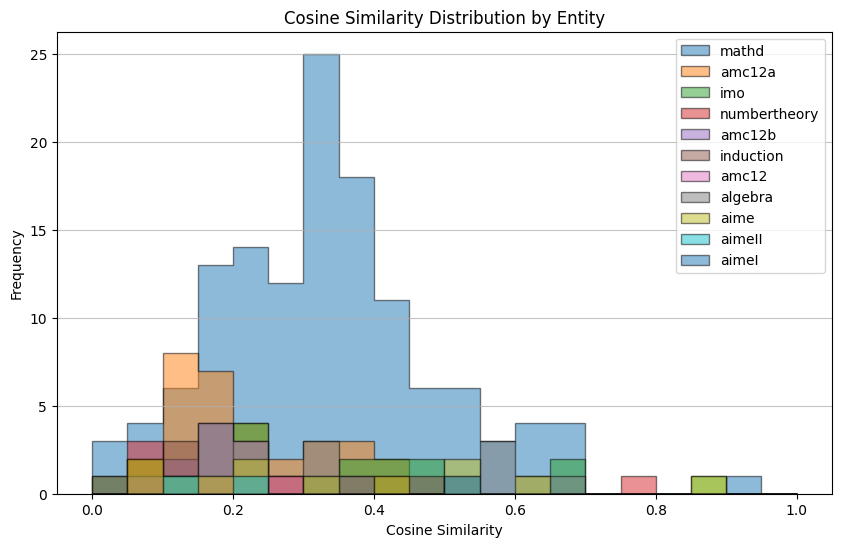

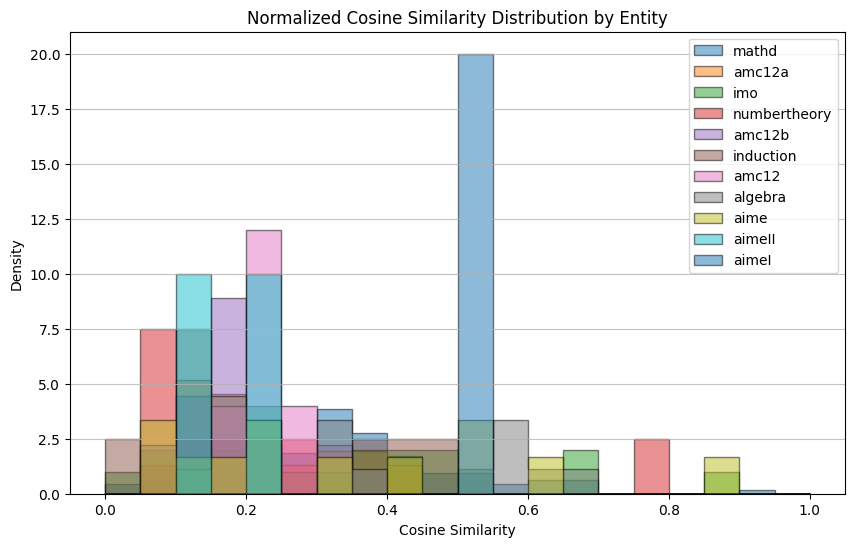

In [2]:
# Perform cosine similarity comparison between gpt_natural_s and natural_s
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import os

# Load results from file
with open('/Users/hmmoore/Desktop/AutoFormalization/Data/gpt_translations_latex.json', 'r') as f:
    results = json.load(f)

similarities = {}
vectorizer = TfidfVectorizer()

for entry, data in results.items():
    texts = [data['natural_s'], data['gpt_natural_s']]
    tfidf = vectorizer.fit_transform(texts)
    sim = cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
    similarities[entry] = sim

print(f"Average Cosine Similarity: {np.mean(list(similarities.values())):.4f}")

# Create distribution of similarities
similarity_values = list(similarities.values())
plt.hist(similarity_values, bins=20, edgecolor='black')
plt.title('Distribution of Cosine Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Distribution of Cosine Similarities by entity name (first part before underscore)
entity_groups = defaultdict(list)
for entry, sim in similarities.items():
    entity = entry.split('_')[0]
    entity_groups[entity].append(sim)

# Plot each entity's distribution
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
plt.figure(figsize=(10, 6))
for entity, sims in entity_groups.items():
    plt.hist(sims, bins=bins, alpha=0.5, label=entity, edgecolor='black', histtype='stepfilled')
plt.title('Cosine Similarity Distribution by Entity')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(10, 6))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
for entity, sims in entity_groups.items():
    plt.hist(sims, bins=bins, alpha=0.5, label=entity, density=True, edgecolor='black', histtype='stepfilled')
plt.title('Normalized Cosine Similarity Distribution by Entity')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:

# --- Imports with graceful fallbacks ---
import math
from typing import List, Tuple, Dict, Optional
import re

# Semantic: prefer SBERT; fallback to TF‑IDF cosine
try:
    from sentence_transformers import SentenceTransformer
    import numpy as np
    _SBERT_AVAILABLE = True
except Exception:
    _SBERT_AVAILABLE = False
    import numpy as np

# TF‑IDF fallback
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity as sk_cos
    _SKLEARN_AVAILABLE = True
except Exception:
    _SKLEARN_AVAILABLE = False

# Grammar: prefer spaCy; fallback to simple heuristics
try:
    import spacy
    _SPACY_AVAILABLE = True
    try:
        nlp = spacy.load("en_core_web_sm")
    except Exception:
        # Try a blank English model as a degraded fallback
        nlp = spacy.blank("en")
except Exception:
    _SPACY_AVAILABLE = False
    nlp = None

def _cosine(a: np.ndarray, b: np.ndarray) -> float:
    num = float((a*b).sum())
    den = float(np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)
    return num / den

# ---------------- Semantic similarity ----------------
_sbert_model = None

def _get_sbert():
    global _sbert_model
    if _sbert_model is None and _SBERT_AVAILABLE:
        # try:
        _sbert_model = SentenceTransformer("/Users/hmmoore/Desktop/AutoFormalization/sentence-transformers/all-MiniLM-L6-v2")
        # except Exception:
        #     print("Warning: Could not load SBERT model; proceeding without it.")
        #     # Model not cached/offline; disable SBERT path
        #     _sbert_model = None
    return _sbert_model

def semantic_similarity(a: str, b: str) -> float:
    """Return a cosine similarity in [0,1].
    - Prefers SBERT embeddings if available and model is loadable.
    - Falls back to TF‑IDF cosine if sklearn is available.
    - Final fallback: Jaccard of word sets.
    """
    a = (a or "").strip()
    b = (b or "").strip()
    if not a and not b: return 1.0
    if not a or not b:  return 0.0

    model = _get_sbert()
    if model is not None:
        try:
            vecs = model.encode([a, b], normalize_embeddings=True)
            sim = float((vecs[0] * vecs[1]).sum())
            # already normalized, so dot = cosine
            return max(0.0, min(1.0, sim))
        except Exception:
            pass

    if _SKLEARN_AVAILABLE:
        try:
            tfidf = TfidfVectorizer(min_df=1, max_features=20000, ngram_range=(1,2))
            X = tfidf.fit_transform([a, b])
            sim = float(sk_cos(X[0], X[1])[0,0])
            return max(0.0, min(1.0, sim))
        except Exception:
            pass

    # Last-resort: Jaccard similarity on lowercased tokens
    A = set(re.findall(r"[A-Za-z0-9]+", a.lower()))
    B = set(re.findall(r"[A-Za-z0-9]+", b.lower()))
    if not A and not B: return 1.0
    if not A or not B:  return 0.0
    sim = len(A & B) / max(1, len(A | B))
    return float(sim)

# ---------------- Grammatical similarity ----------------
def _pos_tags(text: str) -> list:
    if _SPACY_AVAILABLE and nlp is not None:
        try:
            doc = nlp(text)
            return [t.pos_ or "X" for t in doc]
        except Exception:
            pass
    # Heuristic POS buckets (very rough fallback)
    tokens = re.findall(r"[A-Za-z']+|[0-9]+|[^\sA-Za-z0-9]", text)
    tags = []
    for tok in tokens:
        if re.fullmatch(r"[0-9]+", tok):
            tags.append("NUM")
        elif tok.lower() in {"and","or","but"}:
            tags.append("CCONJ")
        elif tok.lower() in {"a","an","the"}:
            tags.append("DET")
        elif tok.endswith("ing"):
            tags.append("VERB")
        elif tok.lower() in {"is","are","was","were","be","been","being"}:
            tags.append("AUX")
        else:
            tags.append("X")
    return tags

def _dependency_subtrees(text: str) -> int:
    """Approximate number of dependency subtrees.
    With spaCy: count children-rooted spans.
    Fallback: count commas, 'and', 'or' as crude subtree signals.
    """
    if _SPACY_AVAILABLE and nlp is not None and hasattr(nlp, "pipe"):
        try:
            doc = nlp(text)
            # number of tokens that have at least one child
            return sum(1 for t in doc if len(list(t.children))>0) or 1
        except Exception:
            pass
    # crude heuristic
    return max(1, text.count(",") + len(re.findall(r"\b(and|or)\b", text.lower())) + 1)

def grammar_similarity(a: str, b: str) -> float:
    # Tree structure similarity
    T1 = _dependency_subtrees(a)
    T2 = _dependency_subtrees(b)
    stree = 1.0 - abs(T1 - T2) / max(T1, T2, 1)

    # POS tag overlap
    P1 = _pos_tags(a)
    P2 = _pos_tags(b)
    # multiset-style overlap via min-counts
    from collections import Counter
    c1, c2 = Counter(P1), Counter(P2)
    inter = sum(min(c1[t], c2[t]) for t in set(c1)|set(c2))
    spos = inter / max(len(P1), len(P2), 1)

    return float(max(0.0, min(1.0, (stree + spos)/2.0)))

# ---------------- Syntactic / Lexical features ----------------
def _syntactic_depth_approx(text: str) -> int:
    """Approximate syntactic depth.
    If spaCy is available, use max dependency distance.
    Fallback: count of clauses/markers as proxy.
    """
    if _SPACY_AVAILABLE and nlp is not None:
        try:
            doc = nlp(text)
            depth = 0
            for i,t in enumerate(doc):
                head_i = t.head.i if t.head is not None else i
                depth = max(depth, abs(head_i - i))
            return int(depth)
        except Exception:
            pass
    # crude proxy: commas + subordinators + relative pronouns
    markers = re.findall(r"\b(that|which|who|whom|because|although|while|when|if)\b", text.lower())
    return text.count(",") + len(markers) + len(re.findall(r"\b(and|or)\b", text.lower()))

def _lexical_diversity(text: str) -> float:
    toks = re.findall(r"[A-Za-z0-9]+", text.lower())
    if not toks: return 0.0
    return len(set(toks)) / len(toks)

def nl_stats(text: str) -> Dict[str, float]:
    toks = re.findall(r"[A-Za-z0-9]+|[^\sA-Za-z0-9]", text)
    return {
        "length_tokens": len(toks),
        "syntactic_depth": _syntactic_depth_approx(text),
        "lexical_diversity": _lexical_diversity(text),
    }

# ---------------- Accuracy adjustment ----------------
def adjusted_accuracy(A_para: float, CS: float) -> Tuple[float, float, float]:
    """Return (A_true_low, A_true_est, A_true_high).
    Using A_true = A_para ± (1 - CS) * A_para
    We interpret 'est' as A_para, and bounds using ± term.
    """
    CS = max(0.0, min(1.0, CS))
    delta = (1.0 - CS) * A_para
    return (max(0.0, A_para - delta), A_para, min(1.0, A_para + delta))


/Users/hmmoore/miniconda3/envs/BIRD/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ---- FORCE OFFLINE, NO SBERT PATHS ----
import pandas as pd
from IPython.display import display
import os, re

# Deterministic TF-IDF cosine (no network)
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity as _sk_cos
except Exception as e:
    raise ImportError("scikit-learn is required for offline cosine. pip install scikit-learn") from e

# Build a fresh vectorizer per pair to avoid leakage; robust for short strings
def _tfidf_cosine(a: str, b: str) -> float:
    a, b = (a or "").strip(), (b or "").strip()
    if not a and not b: return 1.0
    if not a or not b:  return 0.0
    tfidf = TfidfVectorizer(min_df=1, max_features=20000, ngram_range=(1,2))
    X = tfidf.fit_transform([a, b])
    return float(_sk_cos(X[0], X[1])[0,0])

# Override ANY earlier semantic_similarity to ensure no SBERT is used in THIS cell
def semantic_similarity(a: str, b: str) -> float:
    return _tfidf_cosine(a, b)

# Keep your existing grammar_similarity / nl_stats / adjusted_accuracy from earlier cells.
# If they aren't defined yet in your notebook, define minimal fallbacks here:
try:
    grammar_similarity
except NameError:
    def grammar_similarity(a: str, b: str) -> float:
        # Minimal safe fallback: token Jaccard on rough POS-ish buckets
        def _toks(s): return re.findall(r"[A-Za-z0-9]+", s.lower())
        A, B = set(_toks(a)), set(_toks(b))
        if not A and not B: return 1.0
        if not A or not B:  return 0.0
        return len(A & B)/len(A | B)

try:
    nl_stats
except NameError:
    def nl_stats(text: str):
        toks = re.findall(r"[A-Za-z0-9]+|[^\sA-Za-z0-9]", text or "")
        def _lexdiv(ts):
            w = [t for t in ts if re.match(r"[A-Za-z0-9]+", t)]
            return (len(set(w))/len(w)) if w else 0.0
        # crude depth proxy
        depth = text.count(",") + len(re.findall(r"\b(and|or|that|which|who|whom|because|although|while|when|if)\b", (text or "").lower()))
        return {"length_tokens": len(toks), "syntactic_depth": depth, "lexical_diversity": _lexdiv(toks)}

try:
    adjusted_accuracy
except NameError:
    def adjusted_accuracy(A_para: float, CS: float):
        CS = max(0.0, min(1.0, CS))
        delta = (1.0 - CS) * A_para
        return (max(0.0, A_para - delta), A_para, min(1.0, A_para + delta))

# ---------- Build dataframe from your 'results' dict ----------
csv_path = None  # set to a real path if you actually have a CSV
if csv_path and os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    if 'results' not in globals():
        raise NameError("Expected a 'results' dict in scope, or set a valid 'csv_path'.")
    records = []
    for entry, data in results.items():
        records.append({
            "formal": entry,
            "nl_reference": data.get('natural_s', ''),
            "nl_generated": data.get('gpt_natural_s', '')
        })
    df = pd.DataFrame.from_records(records)

# ---------- Compute metrics (OFFLINE ONLY) ----------
rows = []
for _, r in df.iterrows():
    ref = str(r.get("nl_reference", "") or "").strip()
    gen = str(r.get("nl_generated", "") or "").strip()

    sem  = semantic_similarity(ref, gen)  # TF-IDF cosine
    gram = grammar_similarity(ref, gen)
    cos  = _tfidf_cosine(ref, gen)        # explicit cosine column (same TF-IDF)

    ref_stats = nl_stats(ref)
    gen_stats = nl_stats(gen)

    rows.append({
        "formal": r.get("formal",""),
        "semantic_similarity": sem,
        "cosine_similarity": cos,
        "grammar_similarity": gram,
        "ref_length_tokens": ref_stats["length_tokens"],
        "gen_length_tokens": gen_stats["length_tokens"],
        "ref_syntactic_depth": ref_stats["syntactic_depth"],
        "gen_syntactic_depth": gen_stats["syntactic_depth"],
        "ref_lexical_diversity": ref_stats["lexical_diversity"],
        "gen_lexical_diversity": gen_stats["lexical_diversity"],
    })

res = pd.DataFrame(rows)

# Adjusted accuracy using semantic similarity as CS (confidence)
A_para = 0.75  # set to your measured paraphrase accuracy
res["A_true_low"], res["A_true_est"], res["A_true_high"] = zip(
    *[adjusted_accuracy(A_para, cs) for cs in res["semantic_similarity"]]
)

summary = {
    "n_pairs": len(res),
    "mean_semantic_similarity": float(res["semantic_similarity"].mean()) if len(res) else float('nan'),
    "median_semantic_similarity": float(res["semantic_similarity"].median()) if len(res) else float('nan'),
    "mean_cosine_similarity": float(res["cosine_similarity"].mean()) if len(res) else float('nan'),
    "mean_grammar_similarity": float(res["grammar_similarity"].mean()) if len(res) else float('nan'),
    "A_para_input": A_para,
    "A_true_low_mean": float(res["A_true_low"].mean()) if len(res) else float('nan'),
    "A_true_high_mean": float(res["A_true_high"].mean()) if len(res) else float('nan'),
}

display(res)
print("\nSummary:")
for k, v in summary.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")


,formal,semantic_similarity,cosine_similarity,grammar_similarity,ref_length_tokens,gen_length_tokens,ref_syntactic_depth,gen_syntactic_depth,ref_lexical_diversity,gen_lexical_diversity,A_true_low,A_true_est,A_true_high
0,mathd_algebra_151,0.026504,0.026504,0.493243,37,25,1,1,0.833333,0.625000,0.019878,0.75,1.0
1,amc12a_2019_p9,0.127240,0.127240,0.748884,191,126,6,8,0.563218,0.532258,0.095430,0.75,1.0
2,amc12a_2009_p5,0.073502,0.073502,0.425000,120,42,5,3,0.597015,0.631579,0.055127,0.75,1.0
3,mathd_algebra_11,0.272268,0.272268,0.375000,45,79,2,8,0.833333,0.636364,0.204201,0.75,1.0
4,amc12a_2013_p8,0.176066,0.176066,0.662879,132,77,5,6,0.518519,0.600000,0.132050,0.75,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,mathd_numbertheory_458,0.061036,0.061036,0.761905,44,39,5,4,0.789474,0.761905,0.045777,0.75,1.0
240,mathd_numbertheory_780,0.175674,0.175674,0.585714,55,70,3,7,0.677419,0.735294,0.131755,0.75,1.0
241,amc12a_2002_p21,0.173552,0.173552,0.848693,153,124,11,10,0.569767,0.661017,0.130164,0.75,1.0
242,mathd_algebra_126,0.154265,0.154265,0.747978,53,52,7,5,0.833333,0.772727,0.115699,0.75,1.0



Summary:
n_pairs: 244.0000
mean_semantic_similarity: 0.1973
median_semantic_similarity: 0.1651
mean_cosine_similarity: 0.1973
mean_grammar_similarity: 0.6695
A_para_input: 0.7500
A_true_low_mean: 0.1480
A_true_high_mean: 0.9988


## Category-based distribution plots
We derive `formal_category` by splitting `formal` on `_` and taking the first token, then show distribution plots for counts and metric distributions.


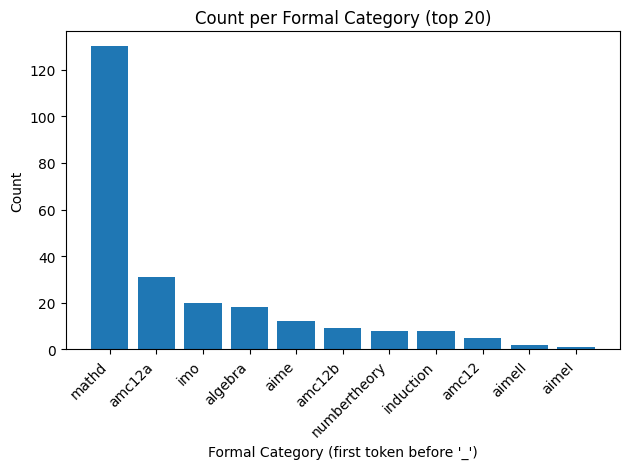

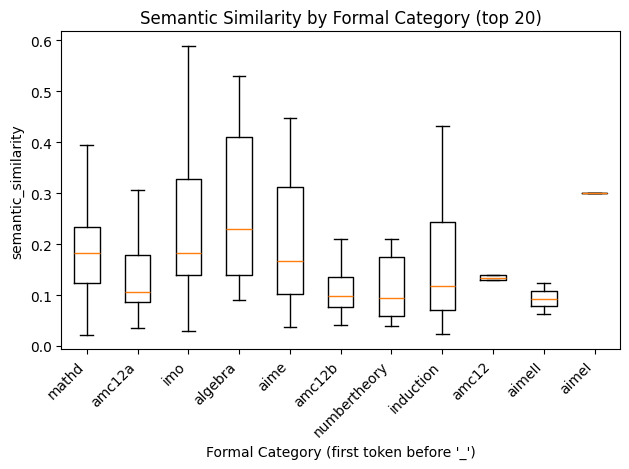

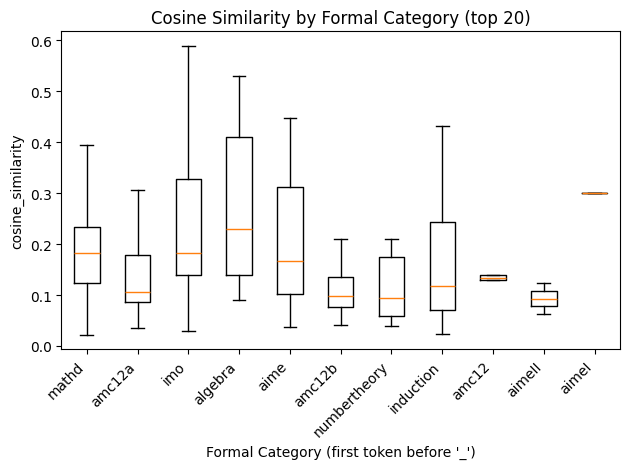

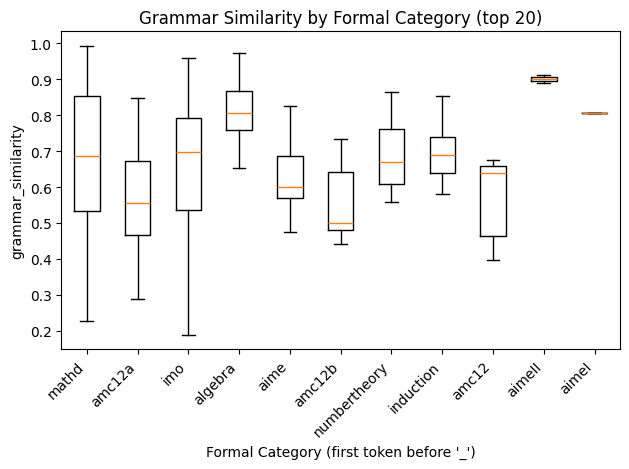

In [5]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

if 'res' not in globals():
    raise NameError("Expected DataFrame `res` from the previous cell. Please run the metrics cell first.")

# Derive category
cat_df = res.copy()
def _first_cat(s: str) -> str:
    s = str(s or "")
    parts = s.split("_")
    cat = (parts[0] if parts else "").strip()
    return cat or "uncategorized"
cat_df["formal_category"] = cat_df["formal"].map(_first_cat)

# Top categories
counts = cat_df["formal_category"].value_counts()
top_k = 20
top_cats = list(counts.head(top_k).index)
top_df = cat_df[cat_df["formal_category"].isin(top_cats)].copy()

# 1) Count bar chart
plt.figure()
ax = plt.gca()
ax.bar(range(len(top_cats)), counts.loc[top_cats].values)
ax.set_xticks(range(len(top_cats)))
ax.set_xticklabels(top_cats, rotation=45, ha="right")
ax.set_title("Count per Formal Category (top 20)")
ax.set_xlabel("Formal Category (first token before '_')")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

def _boxplot_metric(metric_name: str, title: str):
    data = [top_df.loc[top_df["formal_category"] == c, metric_name].dropna().values for c in top_cats]
    kept = [(c, d) for c, d in zip(top_cats, data) if len(d) > 0]
    if not kept:
        print(f"No data for {metric_name}.")
        return
    labels, series = zip(*kept)
    plt.figure()
    ax = plt.gca()
    ax.boxplot(series, showfliers=False)
    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_xlabel("Formal Category (first token before '_')")
    ax.set_ylabel(metric_name)
    plt.tight_layout()
    plt.show()

_boxplot_metric("semantic_similarity", "Semantic Similarity by Formal Category (top 20)")
_boxplot_metric("cosine_similarity", "Cosine Similarity by Formal Category (top 20)")
_boxplot_metric("grammar_similarity", "Grammar Similarity by Formal Category (top 20)")
